- 改自动获取文件名
- 改自动获取文件路径

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re 
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

%matplotlib inline

In [2]:
# 自动获取文件名
def get_subfolders(folder_path):
    """获取指定文件夹下的所有子文件夹名称
    
    Args:
        folder_path (str): 目标文件夹路径
    
    Returns:
        list: 子文件夹名称列表
    """
    # 验证路径是否存在
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"文件夹不存在: {folder_path}")
    
    # 获取所有子文件夹名称
    subfolders = [
        name for name in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, name))
    ]
    
    return subfolders

# 定义Min-Max归一化函数
def min_max_normalize(df, feature_range=(0, 1)):
    """
    将DataFrame的每列归一化到指定范围
    :param df: 输入DataFrame
    :param feature_range: 目标范围，默认(0,1)
    :return: 归一化后的DataFrame
    """
    df_normalized = df.copy()
    min_val, max_val = feature_range
    for col in df.columns:
        col_min = df[col].min()
        col_max = df[col].max()
        # 处理数值范围为0的特殊情况（避免除零错误）
        if col_max == col_min:
            df_normalized[col] = min_val
        else:
            df_normalized[col] = (df[col] - col_min) * (max_val - min_val) / (col_max - col_min) + min_val
    return df_normalized

C:\Users\Admin\AppData\Local\Temp\ipykernel_24564\3703148671.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


Epoch 1/50
81/81 [==============================] - 1s 3ms/step - loss: 0.1494 - val_loss: 0.0478
Epoch 2/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0445 - val_loss: 0.0361
Epoch 3/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0401 - val_loss: 0.0345
Epoch 4/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0390 - val_loss: 0.0335
Epoch 5/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0337 - val_loss: 0.0172
Epoch 6/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0109 - val_loss: 0.0086
Epoch 7/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0076 - val_loss: 0.0069
Epoch 8/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 9/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 10/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0054 - val_loss: 0.0053
Epoch 11/50
81/81 [

<Figure size 1500x400 with 0 Axes>

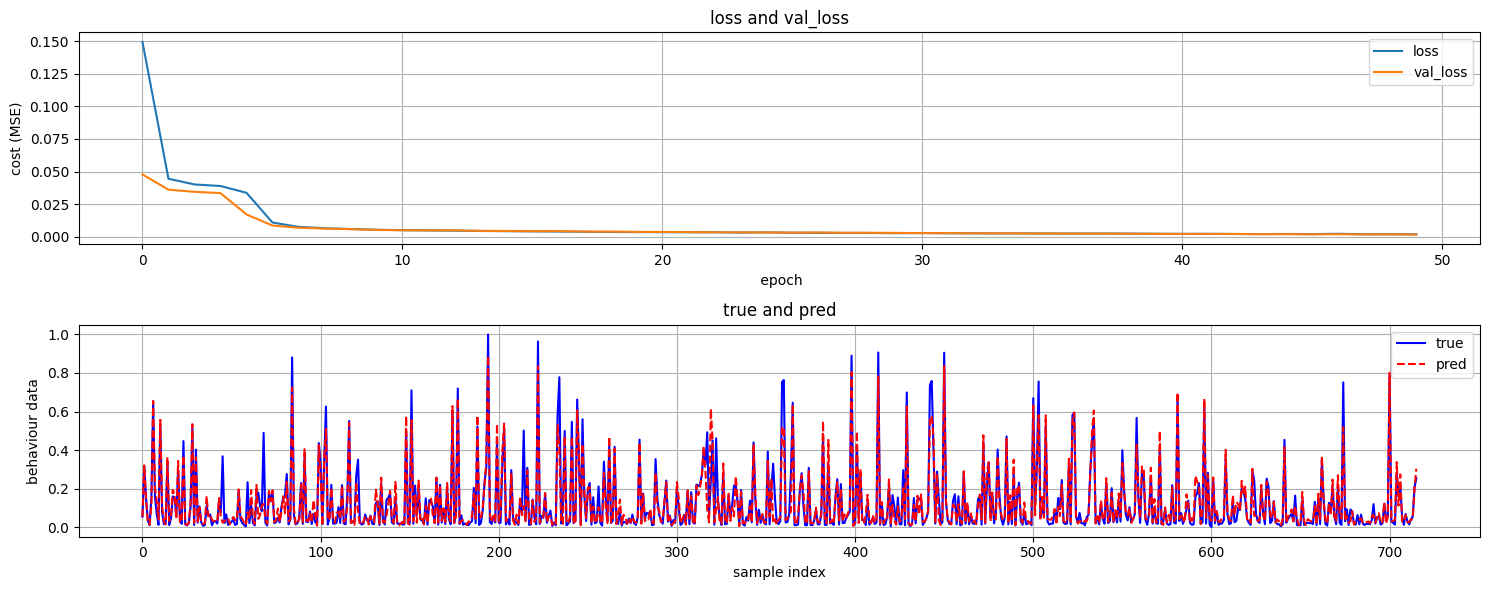

Epoch 1/50


C:\Users\Admin\AppData\Local\Temp\ipykernel_24564\3703148671.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


81/81 [==============================] - 1s 4ms/step - loss: 0.0694 - val_loss: 0.0381
Epoch 2/50
81/81 [==============================] - 0s 3ms/step - loss: 0.0450 - val_loss: 0.0362
Epoch 3/50
81/81 [==============================] - 0s 3ms/step - loss: 0.0442 - val_loss: 0.0357
Epoch 4/50
81/81 [==============================] - 0s 3ms/step - loss: 0.0440 - val_loss: 0.0356
Epoch 5/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0439 - val_loss: 0.0355
Epoch 6/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0438 - val_loss: 0.0354
Epoch 7/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0438 - val_loss: 0.0354
Epoch 8/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0438 - val_loss: 0.0354
Epoch 9/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0438 - val_loss: 0.0354
Epoch 10/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0438 - val_loss: 0.0354
Epoch 11/50
81/81 [===========

<Figure size 1500x400 with 0 Axes>

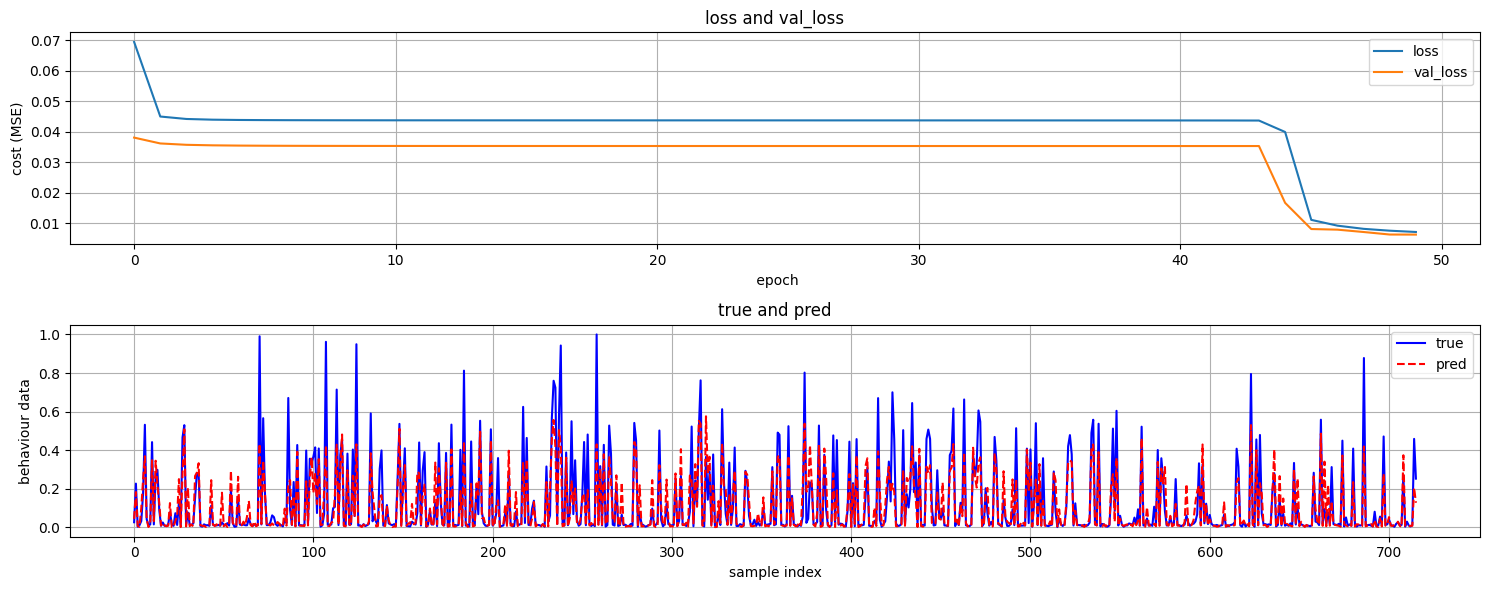

Epoch 1/50


C:\Users\Admin\AppData\Local\Temp\ipykernel_24564\3703148671.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


81/81 [==============================] - 1s 4ms/step - loss: 0.1629 - val_loss: 0.0459
Epoch 2/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0324 - val_loss: 0.0237
Epoch 3/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0258 - val_loss: 0.0208
Epoch 4/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0229 - val_loss: 0.0181
Epoch 5/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0194 - val_loss: 0.0154
Epoch 6/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0170 - val_loss: 0.0135
Epoch 7/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0153 - val_loss: 0.0125
Epoch 8/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0142 - val_loss: 0.0119
Epoch 9/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0133 - val_loss: 0.0114
Epoch 10/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0126 - val_loss: 0.0112
Epoch 11/50
81/81 [===========

<Figure size 1500x400 with 0 Axes>

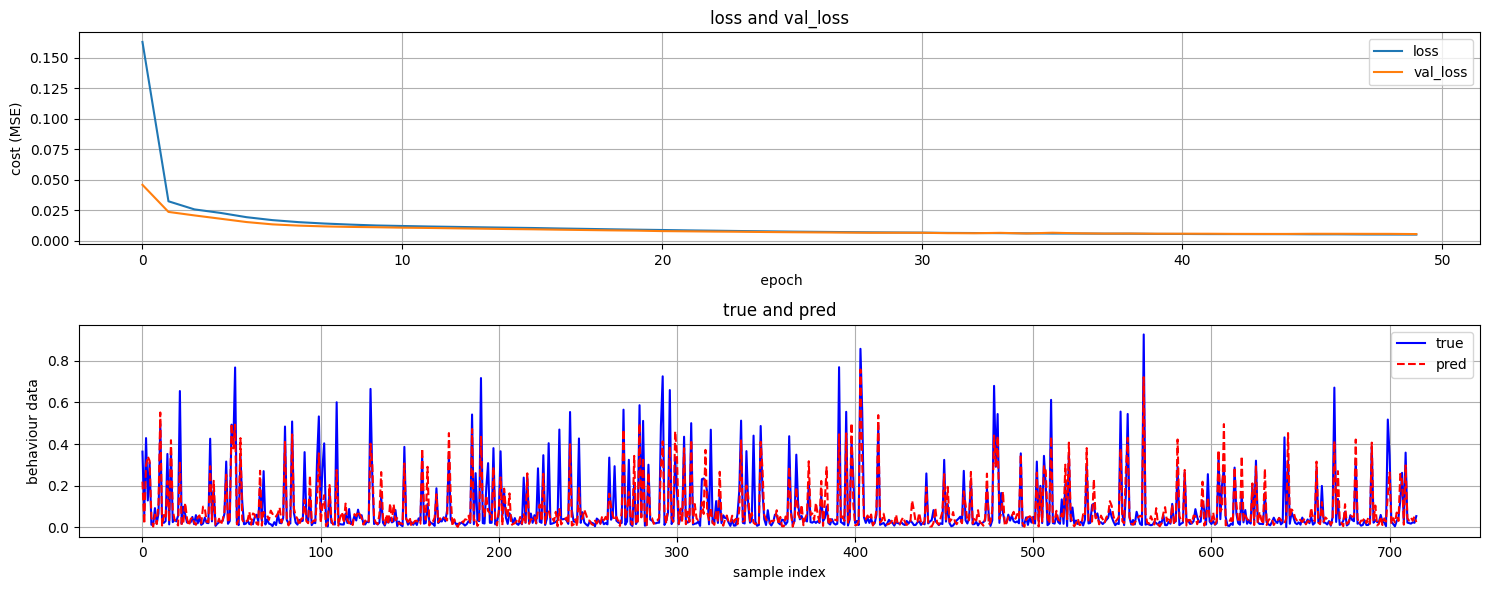

Epoch 1/50


C:\Users\Admin\AppData\Local\Temp\ipykernel_24564\3703148671.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)


81/81 [==============================] - 1s 4ms/step - loss: 0.0568 - val_loss: 0.0225
Epoch 2/50
81/81 [==============================] - 0s 3ms/step - loss: 0.0190 - val_loss: 0.0156
Epoch 3/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0125 - val_loss: 0.0121
Epoch 4/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0100 - val_loss: 0.0109
Epoch 5/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0097 - val_loss: 0.0103
Epoch 6/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0082 - val_loss: 0.0093
Epoch 7/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0079 - val_loss: 0.0090
Epoch 8/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0073 - val_loss: 0.0082
Epoch 9/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0071 - val_loss: 0.0079
Epoch 10/50
81/81 [==============================] - 0s 2ms/step - loss: 0.0064 - val_loss: 0.0074
Epoch 11/50
81/81 [===========

<Figure size 1500x400 with 0 Axes>

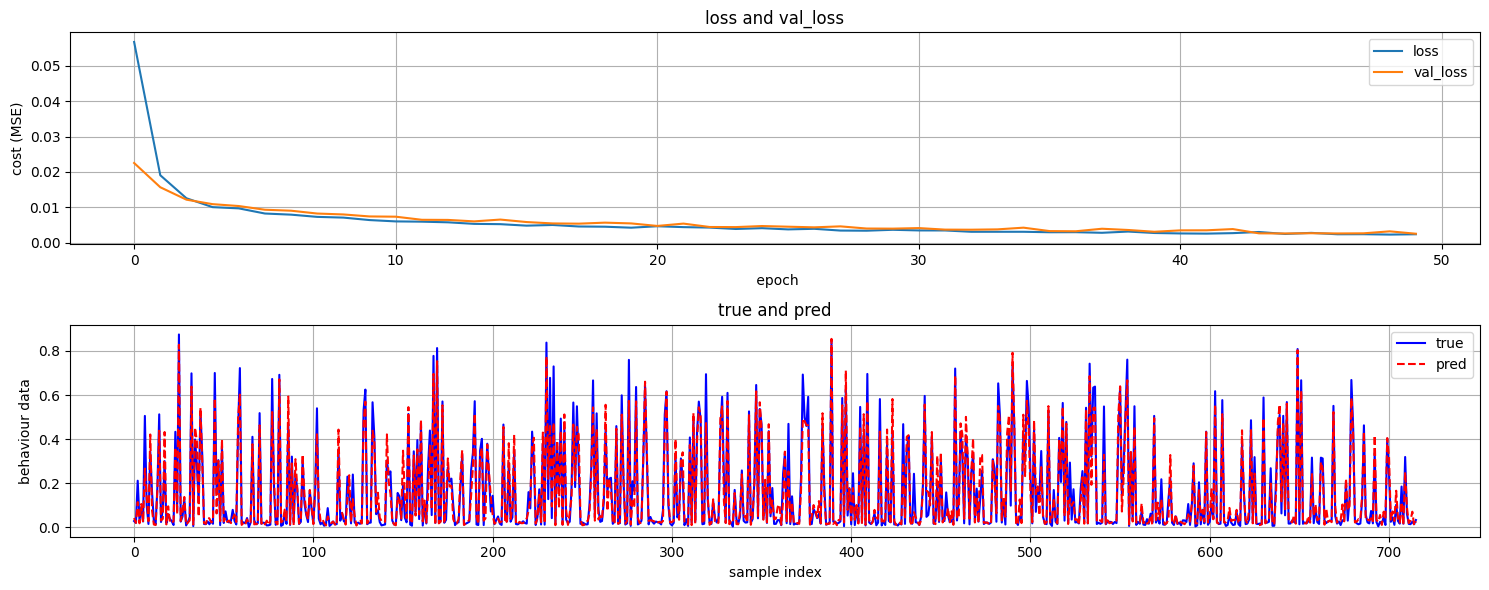

In [ ]:
path_signal = r'D:\XJN\behavior_signaling\VIP'
savepath = r'D:\RQ\M2 Project\summary\Curve Fitting batch one suffle\VIP'
fig_path = savepath

subfolders = get_subfolders(path_signal)

for folder in subfolders:
    folder_path = os.path.join(path_signal, folder)
    savefolder = os.path.join(savepath,folder,'RNN')
    if not os.path.exists(savefolder):
        os.makedirs(savefolder)
    fig_path = savefolder

    # 读取实际数据
    df_signal = pd.read_csv(folder_path+'\\save_result\\C.csv')
    df_raw = pd.read_csv(folder_path+'\\save_result\\YrA.csv')
    # df_im = pd.read_csv(folder_path+'\\im.csv')
    df_behaviour = pd.read_csv(folder_path+'\\Area_Change.csv')
    
    # 确保列名统一
    df_signal = df_signal.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
    df_raw = df_raw.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})

    # Step 1: 手动定义要剔除的 ID 列表
    drop_list = [
    ]  # <-- 人工标注的异常 ID，用户可自由修改

    # Step 2: 以 C 为主，获取有效 ID
    valid_ids = set(df_signal['unit_id'].unique()) - set(drop_list)

    # Step 3: 筛选 YrA 和 C 中的有效 ID
    df_raw = df_raw[df_raw['unit_id'].isin(valid_ids)].copy()
    df_signal = df_signal[df_signal['unit_id'].isin(valid_ids)].copy()

    # Step 4: 重新编号（连续编号）
    # 创建新 id 映射表
    new_id_map = {old_id: new_id for new_id, old_id in enumerate(sorted(valid_ids))}

    # 应用新编号
    df_raw['unit_id'] = df_raw['unit_id'].map(new_id_map)
    df_signal['unit_id'] = df_signal['unit_id'].map(new_id_map)

    # Step 5: 对数据进行下采样，每2帧取平均(可选)

    # def downsample_data(df):
    #     # 确保按unit_id和t排序
    #     df_sorted = df.sort_values(['unit_id', 't']).copy()
    #         # 创建分组键，每3帧一组
    #     df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 3)
    #         # 按unit_id和group分组，计算value的平均值，t取每组的第一个值
    #     df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
    #     return df_downsampled

    def downsample_data(df):
        # 确保按unit_id和t排序
        df_sorted = df.sort_values(['unit_id', 't']).copy()
            # 创建分组键，每3帧一组
        df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 2)
            # 按unit_id和group分组，计算value的平均值，t取每组的第一个值
        df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
        return df_downsampled

    # 应用下采样函数
    df_raw = downsample_data(df_raw)
    # 保存下采样前的数据用于对比
    df_signal_before = df_signal.copy()
    df_signal = downsample_data(df_signal)

    # 2. 标准化 C：按 id 分组
    df = pd.merge(df_raw, df_signal, on=['unit_id', 't'], suffixes=('_YrA', '_C'))
    df['residual'] = df['value_YrA'] - df['value_C']
    df['value_z'] = df['value_C'] / df.groupby('unit_id')['residual'].transform('std')

    # 将行为和信号的数据按照最短的帧数进行截断
    # df_im = df_im.T.reset_index(drop=True)
    df_behaviour = df_behaviour.T.reset_index(drop=True)
    # min_len=min(df.groupby('unit_id').size().min(),len(df_im),len(df_behaviour))
    min_len=min(df.groupby('unit_id').size().min(),len(df_behaviour))

    # df_signal=df_signal.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
    df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
    resized_df_signal_dic_update = df_signal.pivot(index='t', columns='unit_id', values='value_z').reset_index(drop=True)  # 行=时间，列=id
    # df_im_update = df_im[:min_len]
    df_behaviour_update = df_behaviour[:min_len]

    df_behaviour_update_temp = df_behaviour_update.rename(columns={0:'bf'})
    df_signal_total_rf_norm_temp = pd.concat([df_behaviour_update_temp,resized_df_signal_dic_update],axis=1)

    ax = plt.figure(figsize=(15,4))

    correlations = df_signal_total_rf_norm_temp.corrwith(df_behaviour_update_temp.bf).abs()
    correlations.sort_values(ascending=False,inplace=True)

    # correlations.plot.bar()

    # 对两个DataFrame进行归一化
    # 归一化到[0,1]范围
    df_signal_normalized = min_max_normalize(resized_df_signal_dic_update)
    df_behaviour_normalized = min_max_normalize(df_behaviour_update)

    S_train, S_test, B_train, B_test = train_test_split(df_signal_normalized,
                                                    df_behaviour_normalized,
                                                    test_size=0.2,
                                                    random_state=0,
                                                    shuffle = False)
    
    S_train = S_train.reset_index().drop(columns={'index'})
    S_test = S_test.reset_index().drop(columns={'index'})
    B_train = B_train.reset_index().drop(columns={'index'})
    B_test = B_test.reset_index().drop(columns={'index'})

    # 为RNN准备数据格式 [samples, time steps, features]
    # 计算可被20×特征数整除的样本量
    time_steps = 1
    n_features_train = S_train.shape[1]
    n_features_test = S_test.shape[1]
    # 计算最大完整样本数
    # total_elements_train = time_steps * n_features_train
    # total_elements_test = time_steps * n_features_test
    n_samples_train = S_train.shape[0] // time_steps
    n_samples_test = S_test.shape[0] // time_steps

    # 截断数据并重塑
    S_train_rnn = S_train.values[:n_samples_train * time_steps].reshape(n_samples_train, time_steps, n_features_train)
    S_test_rnn = S_test.values[:n_samples_test * time_steps].reshape(n_samples_test, time_steps, n_features_test)

    # 构建RNN模型
    model = Sequential()
    model.add(SimpleRNN(units=50, input_shape=(S_train_rnn.shape[1], S_train_rnn.shape[2]), activation='relu'))
    # model.add(Dense(units=1, activation='relu'))
    model.add(Dense(units=1, activation='softplus'))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 训练模型
    history = model.fit(S_train_rnn, B_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

    # 预测
    B_pred = model.predict(S_test_rnn)

    # 评估模型性能
    mse = mean_squared_error(B_test, B_pred)
    r2 = r2_score(B_test, B_pred)
    print(f'测试集均方误差 (MSE): {mse:.4f}')
    print(f'测试集R²分数: {r2:.4f}')

    # 可视化结果
    plt.figure(figsize=(15, 6))

    # 绘制训练损失和验证损失
    plt.subplot(2, 1, 1)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')

    plt.title('loss and val_loss')
    plt.xlabel(' epoch')
    plt.ylabel('cost (MSE)')
    plt.legend()
    plt.grid(True)

    # 绘制预测值与真实值对比
    plt.subplot(2, 1, 2)
    plt.plot(B_test, label='true', color='blue')
    plt.plot(B_pred, label='pred', color='red', linestyle='--')

    plt.title('true and pred')
    plt.xlabel('sample index')
    plt.ylabel('behaviour data')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # 保存模型（可选）
    # model.save('rnn_behavior_prediction_model.h5')

    B_pred_csv = pd.DataFrame(B_pred).rename(columns={0:'pred'})
    B_test_csv = pd.DataFrame(B_test).rename(columns={0:'test'})
    B_pred_csv.to_csv(savefolder+'/'+'pred.csv',index=False)
    B_test_csv.to_csv(savefolder+'/'+'test.csv',index=False)

    B_pred_temp = pd.DataFrame(B_pred).rename(columns={0:'pred'})
    B_test_temp = pd.DataFrame(B_test).rename(columns={0:'test'})
    B_test_corr = pd.concat([B_pred_temp,B_test_temp],axis=1)

    correlations = B_test_corr.corrwith(B_test_corr.test).abs()
    correlations.to_csv(fig_path+'/'+'correlations.csv',index = False)